In [1]:
from tensorflow import keras

### Interpreting what convnets learn
Techniques for visualizing and interpreting convnet representations:

####(1)Visualizing intermediate activations:
This is useful for understanding how successive convnet layers transform their input, and also for getting  a first idea of the meaning of the individual convnet filters.

This consists of displaying the values returned by various convolution and pooling layers in a model, given a certain input (the output of a layer is often called its activation, the output of the activation function).

We want to visualize feature maps with three dimensions: width, height, and depth (channels).

Lets start by loading the model:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
model = keras.models.load_model("/content/drive/MyDrive/cats_vs_dogs_small/convnet_from_scratch_with_augmentation.keras")

In [4]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,982,084 (7.56 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 991,043 (3.78 MB)

Next we will get input image - a picture of a cat, not the ones the network is trained on.

In [5]:
import numpy as np

In [6]:
img_path = keras.utils.get_file(
    fname='cat.jpg',
    origin='https://img-datasets.s3.amazonaws.com/cat.jpg')   #Download test image

80329/80329 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


In [7]:
def get_img_array(img_path, target_size):
  img = keras.utils.load_img(
      img_path, target_size=target_size)      #open the image file and resize it.

  array = keras.utils.img_to_array(img)    # turns the image into a float32 Numpy array of shape(180, 180, 3)
  array = np.expand_dims(array, axis=0)   # add a dimension to transform the array into a batch of a single sample...
                                            # ..its shape is now(1, 180, 180, 3)
  return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

Lets display the picture:

In [8]:
import matplotlib.pyplot as plt

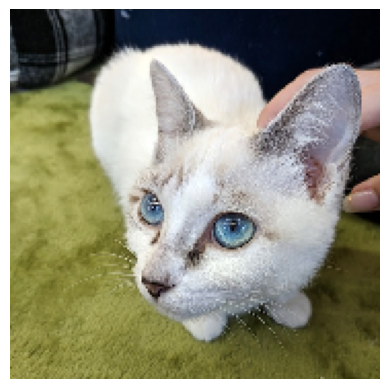

In [9]:
plt.axis('off')
plt.imshow(img_tensor[0].astype('uint8'))
plt.show()

To get the feature maps we want to look at, we will create a keras model that takes batches of images as input, and that outputs the activation of all convolution and pooling layers

Instantiating the model that returns layer activations:

In [10]:
from tensorflow.keras import layers

In [11]:
layer_outputs = []
layer_names = []

for layer in model.layers:
  if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)): #extract the ouputs of all Conv2D and MaxPooling2D layers and put them in a list
    layer_outputs.append(layer.output)
    layer_names.append(layer.name)       # save the layer names for later

activation_model = keras.Model(inputs=model.input, outputs=layer_outputs) #create a model that will return these outputs given the model input.

When fed an image input, this model returns the values of the layer activations in the  original model, as a list. This model is a multi-output model, it has  one input and nine outputs: one output per layer activation

####Using the model to compute layer activations

In [12]:
activations = activation_model.predict(img_tensor) #return a list of nine Numpy arrays: one array per layer activation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


In [13]:
shape = np.array(activations[0]).shape
print(shape)

(1, 178, 178, 32)


example: An activation of the first convolution layer for the cat image input:

In [14]:
#example
first_layer_activation = activations[0]
print(first_layer_activation.shape)

(1, 178, 178, 32)


In [15]:
len(activations)

9

It’s a 178 by 178 feature map with 32 channels.
lets try plotting the fifth channel of the activation of the first layer of the original model:

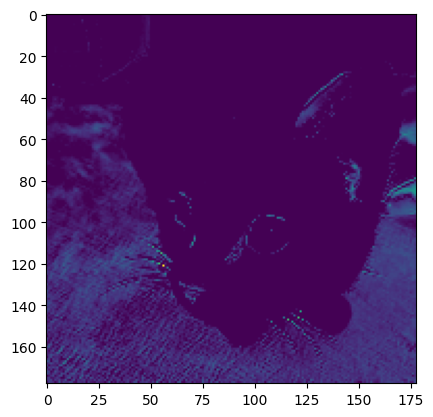

In [16]:

plt.imshow(first_layer_activation[0, :, :, 5], cmap='viridis')

Seems this channel is edge senstive, with brighter activations around the face and ear.

### Visualizing every channel in every intermediate layer

In [17]:
layer_names

['conv2d_14',
 'max_pooling2d_10',
 'conv2d_15',
 'max_pooling2d_11',
 'conv2d_16',
 'max_pooling2d_12',
 'conv2d_17',
 'max_pooling2d_13',
 'conv2d_18']

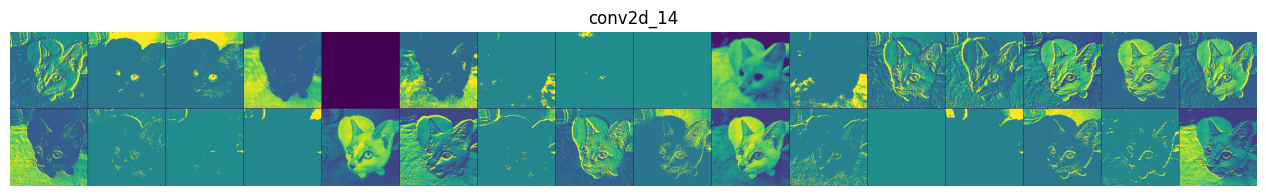

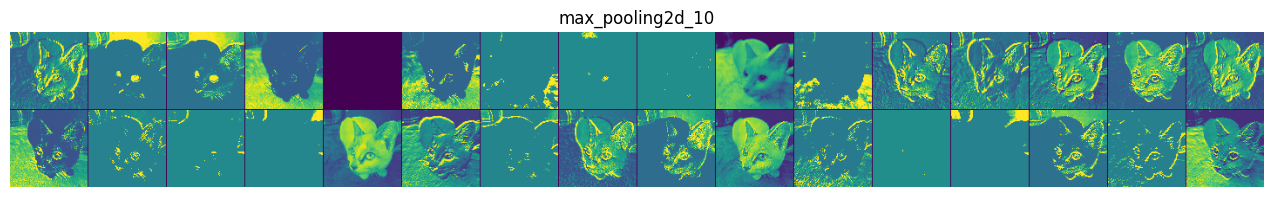

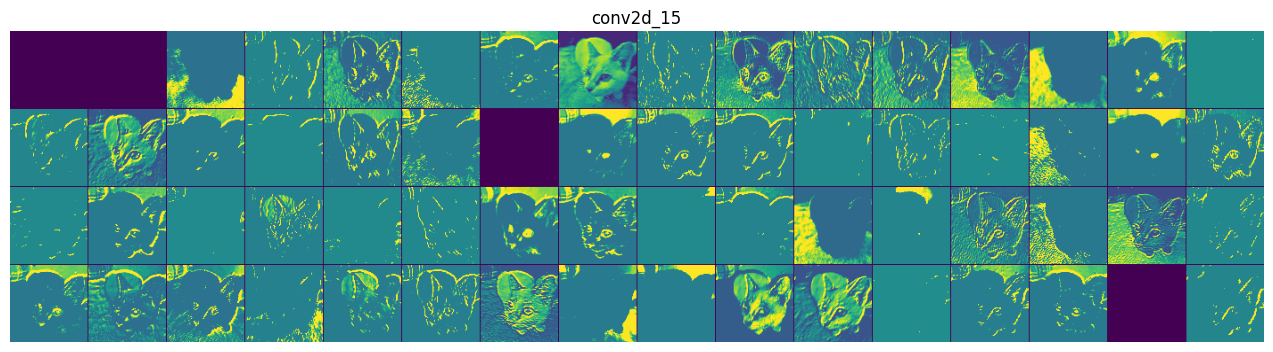

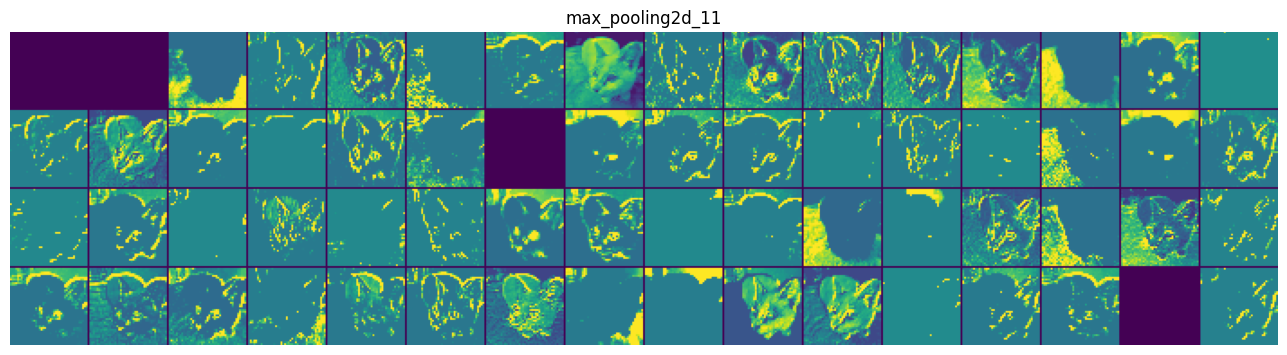

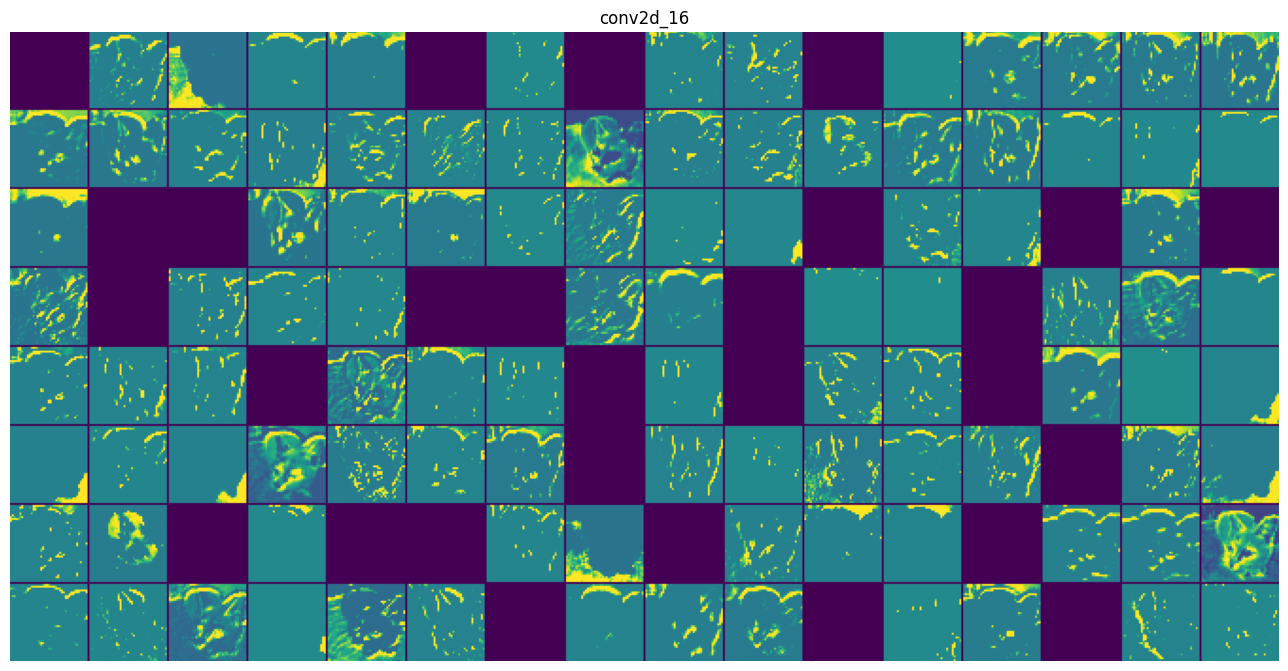

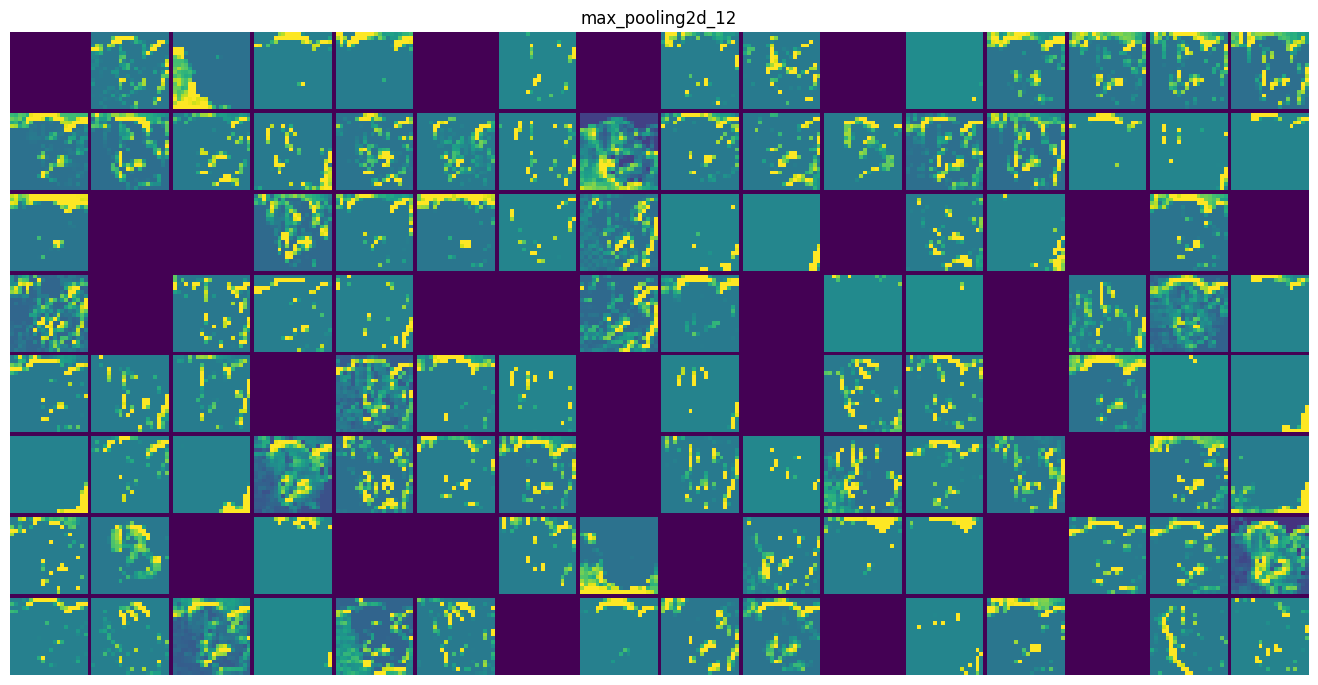

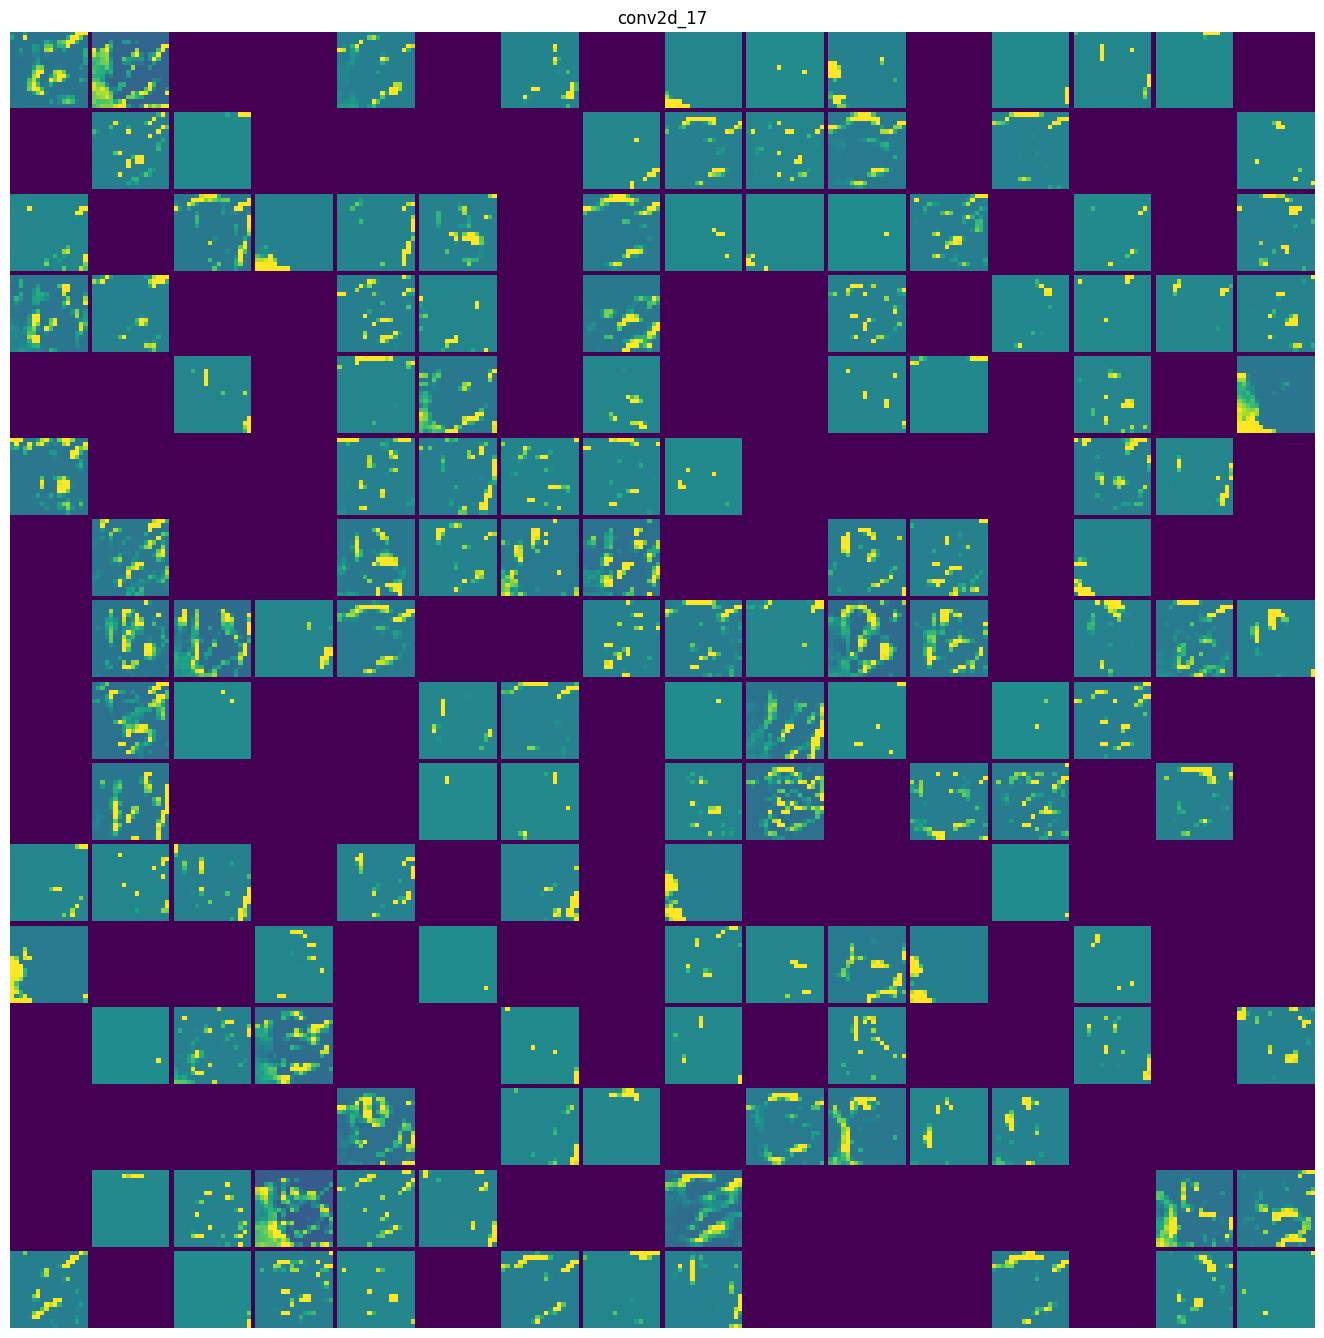

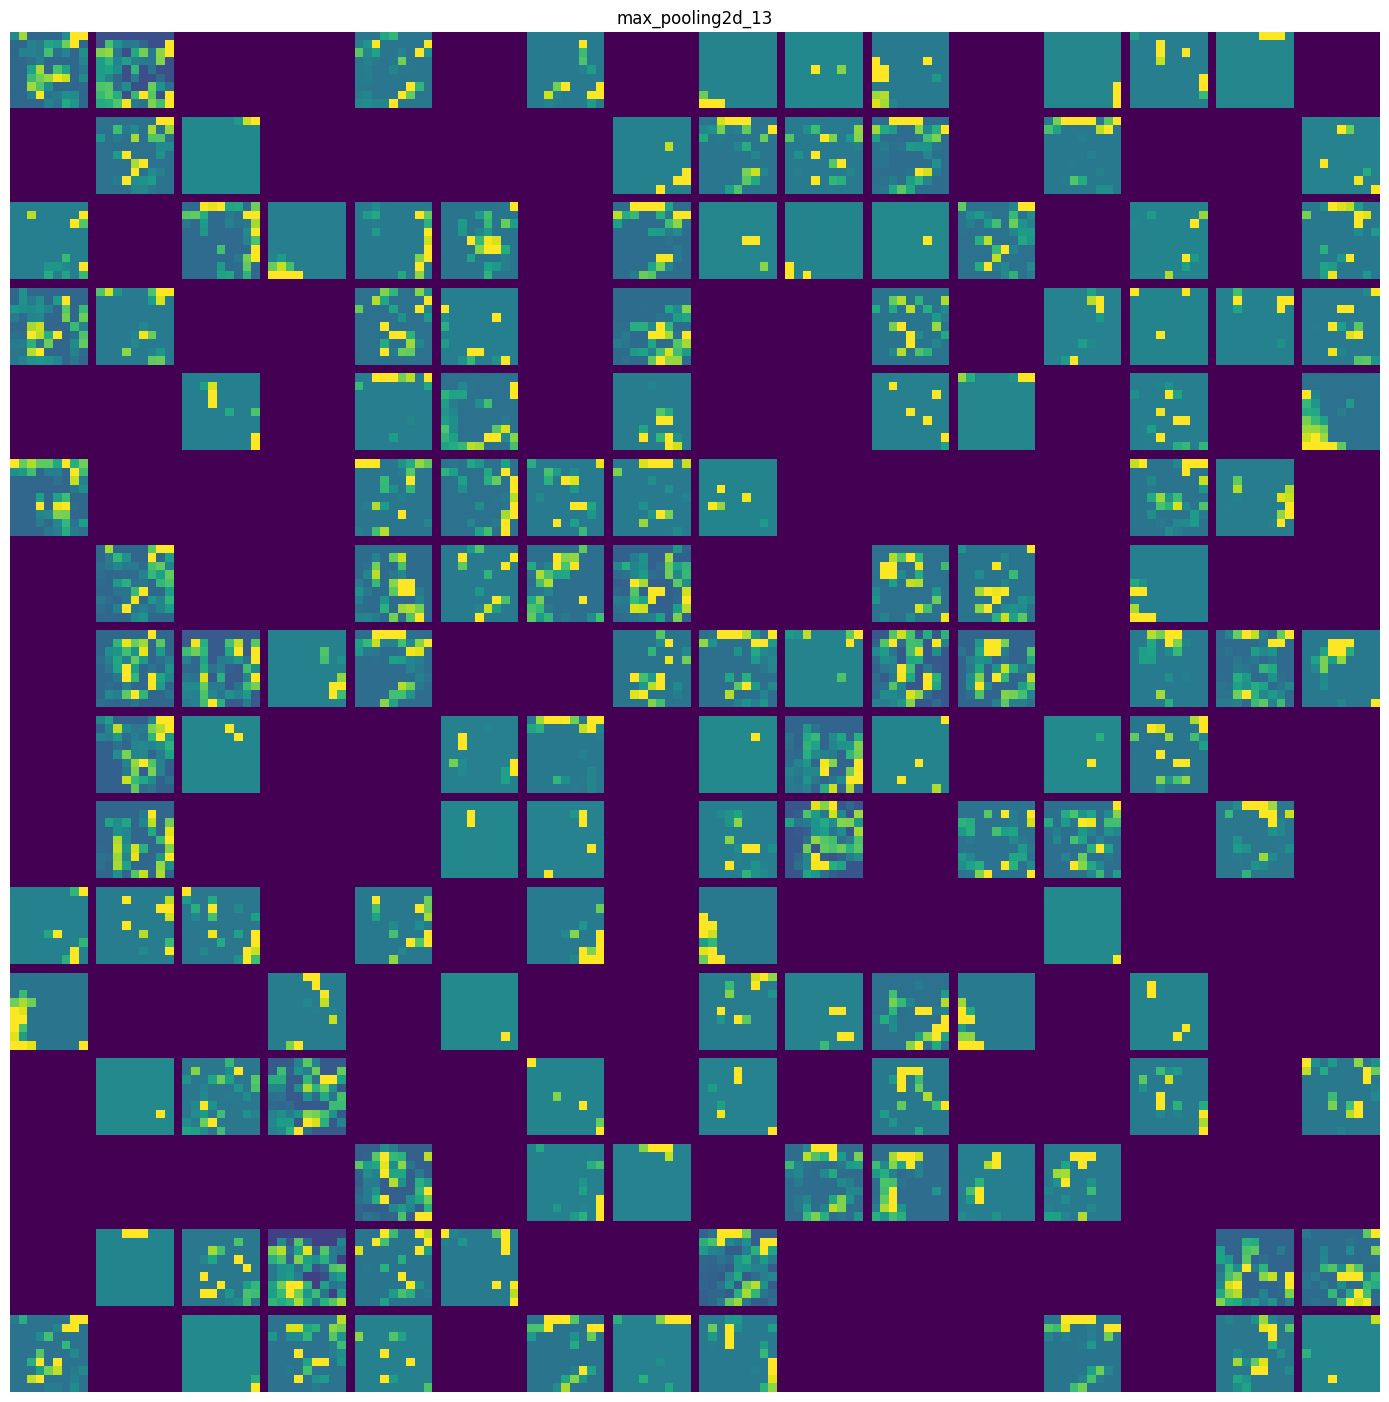

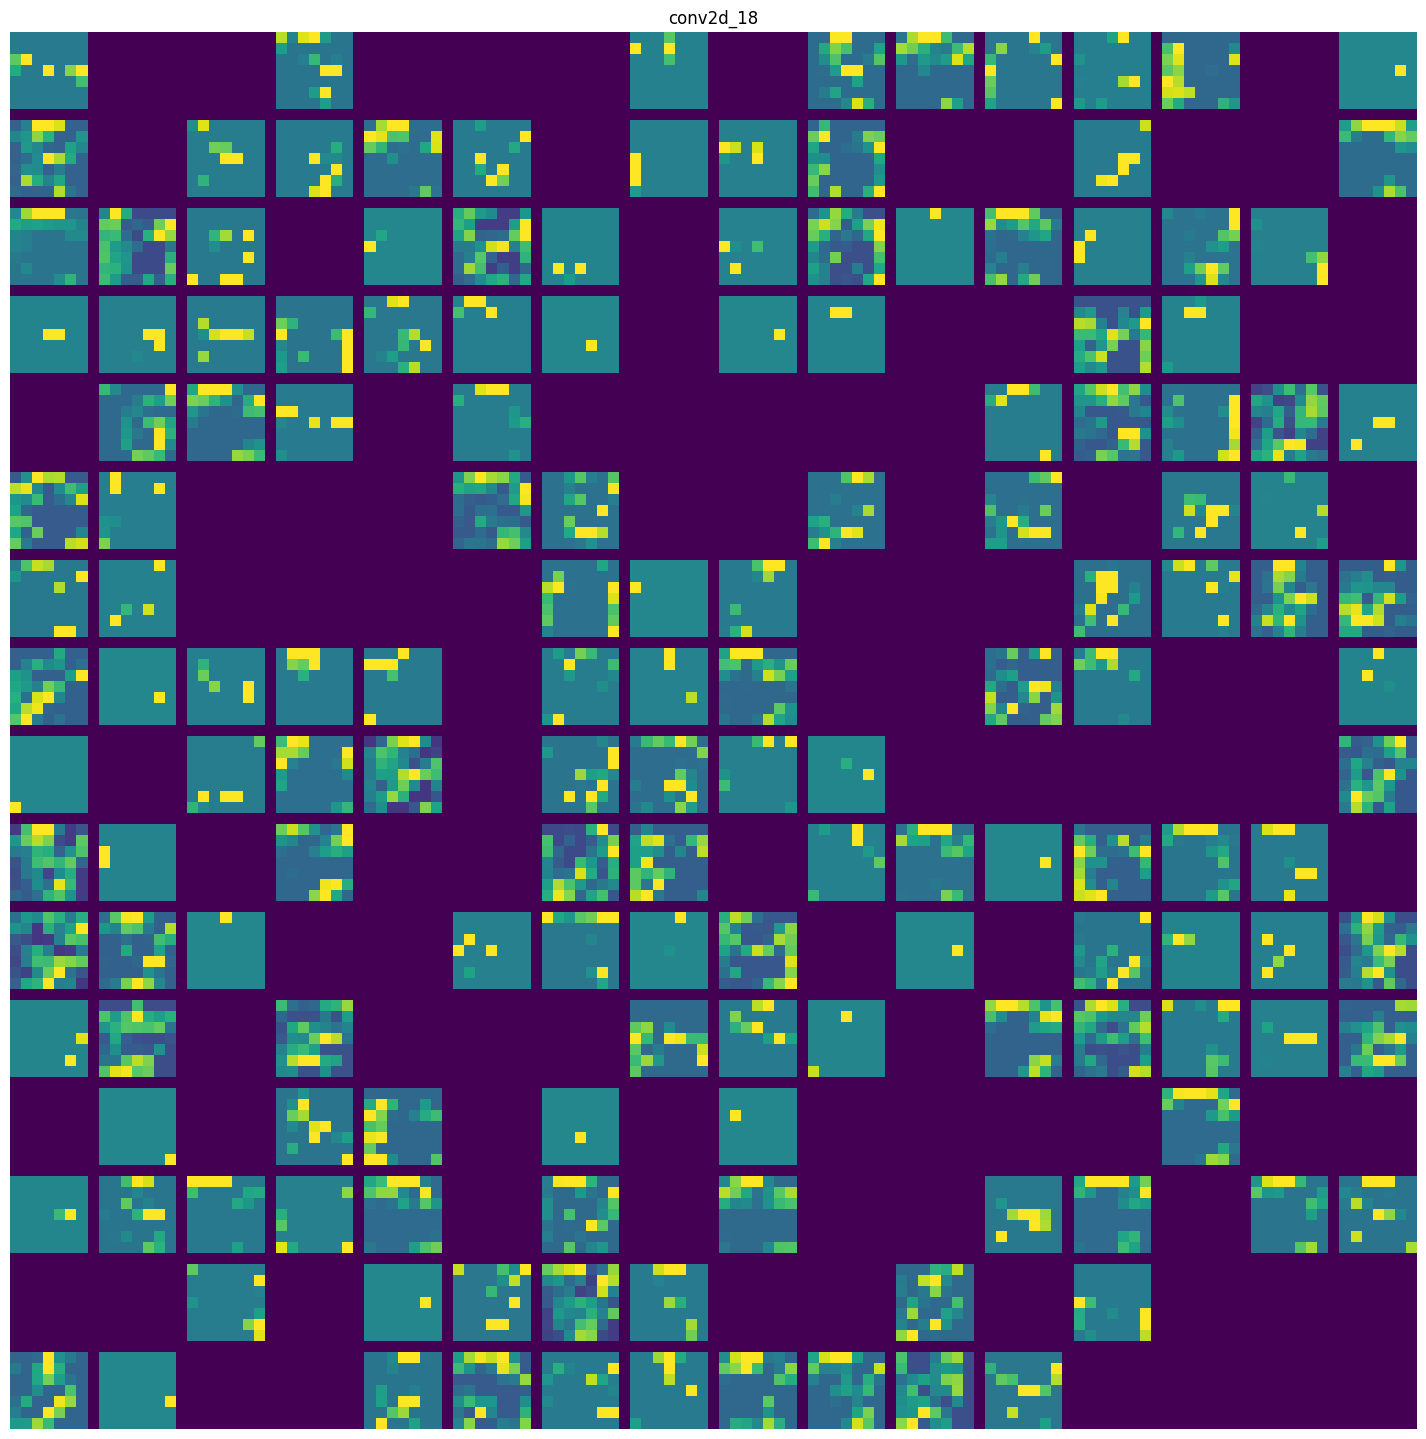

In [18]:
images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations): #iterate over the activations and the names of the corresponding layers.
  n_features = layer_activation.shape[-1]   # The layer_activation has shape (1, size, size, n_features)
  size = layer_activation.shape[1]
  n_cols = n_features // images_per_row
  display_grid = np.zeros(((size + 1) * n_cols - 1, (size + 1) * images_per_row - 1)) #prepare an empty grid for displaying all the channels...
                                                                                      #... in this activation
  for col in range(n_cols):
    for row in range(images_per_row):
      channel_index = col * images_per_row + row
      channel_image = layer_activation[0, :, :, channel_index].copy()

      if channel_image.sum() != 0:
        channel_image -= channel_image.mean()
        channel_image /= channel_image.std()
        channel_image *= 64
        channel_image += 128
      channel_image = np.clip(channel_image, 0, 255).astype('uint8')
      display_grid[col * (size + 1): (col + 1) * size + col,
                   row * (size + 1) : (row + 1) * size + row] = channel_image

  scale = 1. / size
  plt.figure(figsize=(scale * display_grid.shape[1],
                      scale * display_grid.shape[0]))
  plt.title(layer_name)
  plt.grid(False)
  plt.axis('off')
  plt.imshow(display_grid, aspect='auto', cmap='viridis')

Some things to take from this

(1) The first layer collects edge detectors. the activation at this stage still retains almost all the features from the picture.

(2) AS we move deeper, the activations become increasingly abstract and very hard to interprete.This is because they begin to encode higher level features such as eyes and ears. Meaning: deeper presentations carry increasing less information about the visual contents of the image and increasingly more information related to the class of the image.

(3)The sparsity(not dense) of the activation increase with the depth of the layer: In the first layer, you can see that almost all the filters are activated by the input of the image, but as we go deeper, more and more layers are blank. This means the pattern encoded by the filter is not found in the input image.


## Visualizing convnet filters
Another way to inspect the filters learned by convnet is to display the visual pattern that each filter is meant to respond to. This can be done with gradient ascent in input space: applying gradient descent to the value of the input image of a convnet so as to maximize the response of a specific filter, starting from a blank input image.

lets try this with filters of the Xception model, pretrained on Imgenet.

The
process is simple: we will build a loss function that maximizes the value of a given filter
in a given convolution layer, and then we will use stochastic gradient descent to adjust
the values of the input image so as to maximize this activation value.

####Instantiating the Xception convolutional base

In [19]:
model = keras.applications.xception.Xception(
    weights='imagenet',
    include_top=False)      # the classification layers are irrelevent for this use case, so we dont include the top stage of the model.

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [20]:
 # printing names of all convolutional layers in Xception
for layer in model.layers:
  if isinstance(layer, (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
    print(layer.name)

block1_conv1
block1_conv2
block2_sepconv1
block2_sepconv2
conv2d
block3_sepconv1
block3_sepconv2
conv2d_1
block4_sepconv1
block4_sepconv2
conv2d_2
block5_sepconv1
block5_sepconv2
block5_sepconv3
block6_sepconv1
block6_sepconv2
block6_sepconv3
block7_sepconv1
block7_sepconv2
block7_sepconv3
block8_sepconv1
block8_sepconv2
block8_sepconv3
block9_sepconv1
block9_sepconv2
block9_sepconv3
block10_sepconv1
block10_sepconv2
block10_sepconv3
block11_sepconv1
block11_sepconv2
block11_sepconv3
block12_sepconv1
block12_sepconv2
block12_sepconv3
block13_sepconv1
block13_sepconv2
conv2d_3
block14_sepconv1
block14_sepconv2


#### Creating a feature extractor model

In [21]:
layer_name = "block3_sepconv1" # could replace this name with the name of any of the layer in the exception model.
layer = model.get_layer(name=layer_name)  # this is the layer we are interested in here.
feature_extractor = keras.Model(inputs=model.input, outputs=layer.output) # we used model.input and layer.output to create a model that...
                                                                          #..given an input image, returns the output of our target layer.

To use the above model,simply call it on some input data
#### Using the feature extraction

In [22]:
activation = feature_extractor(keras.applications.xception.preprocess_input(img_tensor))
print(activation.shape)

(1, 44, 44, 256)


In [23]:
#print(activation)

Next, we'll use featuare extractor model to define a function that returns a scaler value quantifying how much a given input image "activates" a given filter in the layer. This is the loss function we will maximize during the gradient ascent process:

In [26]:
import tensorflow as tf

In [27]:
def compute_loss(image, filter_index): #the loss function takes an image tensor and the index fo the filter we are considering( integer)
  activation = feature_extractor(image)
  filter_activation = activation[:, 2:-2, 2:-2, filter_index] #note that we avoid border artifacts by only involving non border pixels in the loss.
  return tf.reduce_mean(filter_activation) # returns the mean of the activation values for the filter.

Lets set up a gradient ascent step function using gradient tape. A trick to help the gradient descent go smoothly: Normalize the gradient tensor by dividing it by its L2 norm (the square root of the average of the square of the values in the tensor)

In [28]:
@tf.function   # to speed it up
def gradient_ascent_step(image, filter_index, learning_rate):
  with tf.GradientTape() as tape:
    tape.watch(image)                          # explicitly watch the image tensor since its not a tensorflow variable
    loss = compute_loss(image, filter_index)   # compute the loss scaler indicating how much the current image activates the filter
  grads = tape.gradient(loss, image)           # compute the gradient of the loss with respect to the image
  grads = tf.math.l2_normalize(grads)          # apply the "gradient normalization trick"
  image += learning_rate * grads               # move the image a little bit in the direction that activates our target filter more strongly
  return image                                 # return the updated image so that we can run the step function in a loop

####  function to generate filter visualization

In [31]:
img_width = 200
img_height = 200

def generate_filter_pattern(filter_index):
  iterations = 30            # number fo gradient ascent steps to apply
  learning_rate = 10         # amplitude of a single step

  image = tf.random.uniform(
      minval=0.5,
      maxval=0.6,
      shape = (1, img_width, img_height, 3)) # initialize an image tensor with random values (the Xception model expects...
                                             #...input values in the range [0,1], so here we pick a range centered on 0.5)
  for i in range(iterations):
    image = gradient_ascent_step(image, filter_index, learning_rate) # repeatedly update the values of the image tensor so as to..
  return image[0].numpy()                                            #..maximize our loss function.